In [1]:
from google.colab import files
uploaded = files.upload()

Saving global_air_quality_dataset.csv to global_air_quality_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [3]:
df = pd.read_csv('global_air_quality_dataset.csv')
print("Shape (rows, columns):", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape (rows, columns): (3660, 13)

Column Names:
 ['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

Data Types:
 Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object

First 5 rows:


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [4]:
df.describe()


,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

print("\nAQI value range:", df['AQI'].min(), "to", df['AQI'].max())

print("\nUnique Cities:", df['City'].nunique())
print("Unique Countries:", df['Country'].nunique())

print("\nSample dates:", df['Date'].unique()[:5])

Missing values per column:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Total duplicate rows: 0

AQI value range: 30 to 300

Unique Cities: 10
Unique Countries: 9

Sample dates: ['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05']


## Phase 1 – Data Reading and Observations

1. The dataset has 3,660 rows and 13 columns.
2. The target variable is AQI (Air Quality Index), ranging from 30 to 300.
3. There are 6 pollutant columns (PM2.5, PM10, NO2, SO2, CO, O3) and 3 weather columns.
4. City and Country are categorical columns that need encoding before modeling.
5. The Date column is stored as text (object) and must be converted into useful numeric features.

Missing values:
 Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Duplicate rows: 0


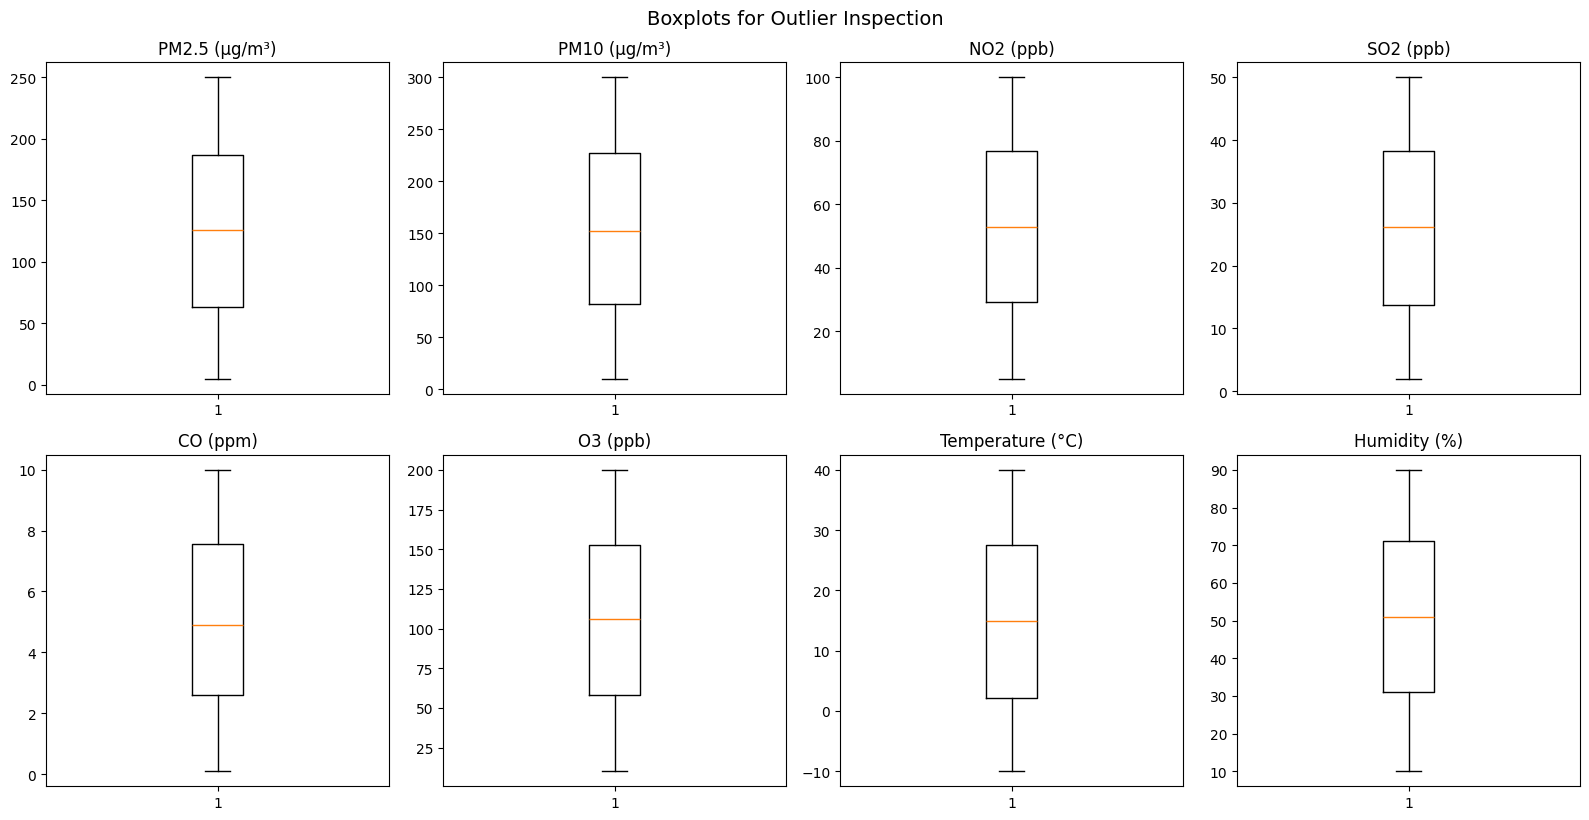


Unique Cities: ['New York' 'Los Angeles' 'London' 'Beijing' 'Delhi' 'Paris' 'Tokyo'
 'Sydney' 'São Paulo' 'Cairo']
Unique Countries: ['USA' 'UK' 'China' 'India' 'France' 'Japan' 'Australia' 'Brazil' 'Egypt']

 Data is clean — no missing values, duplicates, or label inconsistencies found.


In [6]:
#Phase 2:

# 2.1 No missing values found, but we confirm again
print("Missing values:\n", df.isnull().sum())

# 2.2 No duplicates found, but we confirm again
print("\nDuplicate rows:", df.duplicated().sum())

# 2.3 Check for suspicious/outlier values using boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols_to_check = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)',
                 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)',
                 'Temperature (°C)', 'Humidity (%)']

for ax, col in zip(axes.flatten(), cols_to_check):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.suptitle("Boxplots for Outlier Inspection", y=1.02, fontsize=14)
plt.show()

# 2.4 Check City and Country labels for inconsistency
print("\nUnique Cities:", df['City'].unique())
print("Unique Countries:", df['Country'].unique())

print("\n Data is clean — no missing values, duplicates, or label inconsistencies found.")

## Cleaning Notes
- No missing values or duplicate rows were found in this dataset.
- Boxplot inspection showed no extreme outliers requiring removal.
- Negative temperature values are valid (e.g., winter in Sydney, New York).
- City and Country labels are consistent with no typos or case mismatches.
- The Date column will be handled in preprocessing by extracting Month and Year.

In [7]:
#Phase 3: Preprocessing

# 3.1 Extract useful features from Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Day']   = df['Date'].dt.day

# 3.2 Drop the original Date column (not usable directly)
df_model = df.drop(columns=['Date'])

# 3.3 Separate features (X) and target (y)
X = df_model.drop(columns=['AQI'])
y = df_model['AQI']

# 3.4 Identify column types
categorical_cols = ['City', 'Country']
numerical_cols   = [col for col in X.columns if col not in categorical_cols]

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print("Feature matrix shape:", X.shape)

Numerical columns: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Month', 'Year', 'Day']
Categorical columns: ['City', 'Country']
Feature matrix shape: (3660, 14)


In [9]:
#Phase 4: Train / Validation / Test Split

# Step 1: Split off 30% as temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

# Step 2: Split holdout 50/50 → 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training set:   {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\n Test set will NOT be touched until final evaluation.")

Training set:   2562 rows (70.0%)
Validation set: 549 rows (15.0%)
Test set:       549 rows (15.0%)

 Test set will NOT be touched until final evaluation.


In [10]:
#Phase 5: Build Pipeline & Train Model

# Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train on training data only
pipeline.fit(X_train, y_train)

# Predict on validation set
y_val_pred = pipeline.predict(X_val)

# Validation metrics
mae  = mean_absolute_error(y_val, y_val_pred)
mse  = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_val, y_val_pred)

print("── Validation Results ──────────────────")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Show coefficients
ohe_cols = pipeline.named_steps['preprocessor']\
           .named_transformers_['cat']\
           .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + ohe_cols

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': pipeline.named_steps['model'].coef_
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept: {pipeline.named_steps['model'].intercept_:.2f}")
print("\nTop Coefficients:")
print(coef_df.to_string(index=False))

── Validation Results ──────────────────
MAE  : 69.88
MSE  : 6474.28
RMSE : 80.46
R²   : -0.0147

Intercept: 165.60

Top Coefficients:
          Feature   Coefficient
 City_Los Angeles  1.055006e+01
       City_Tokyo  5.073093e+00
    Country_Japan  5.073093e+00
            Month  2.807041e+00
   City_São Paulo  2.097814e+00
   Country_Brazil  2.097814e+00
     PM10 (µg/m³)  1.813485e+00
    Country_India  1.355342e+00
       City_Delhi  1.355342e+00
        NO2 (ppb)  1.033395e+00
     Humidity (%)  9.911235e-01
      Country_USA  7.567038e-01
              Day  5.894183e-01
 Temperature (°C)  4.261530e-01
         O3 (ppb)  3.853950e-01
             Year -2.664535e-15
 Wind Speed (m/s) -1.353680e-01
        SO2 (ppb) -1.449809e-01
         CO (ppm) -4.428209e-01
    Country_Egypt -5.074749e-01
       City_Cairo -5.074749e-01
    PM2.5 (µg/m³) -6.167269e-01
     City_Beijing -1.616585e+00
    Country_China -1.616585e+00
      City_London -1.680369e+00
       Country_UK -1.680369e+00
 

In [25]:
#Phase 6: Refinement

# Define columns WITHOUT Year (all data is 2024 only, Year adds no info)
numerical_only = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)',
                  'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)',
                  'Temperature (°C)', 'Humidity (%)',
                  'Wind Speed (m/s)', 'Month', 'Day']

# Version A: No scaling, with City & Country
preprocessor_A = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_only),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
pipeline_A = Pipeline([('preprocessor', preprocessor_A),
                       ('model', LinearRegression())])
pipeline_A.fit(X_train, y_train)
r2_A = r2_score(y_val, pipeline_A.predict(X_val))
print(f"Version A (no scaling, with City/Country) → R²: {r2_A:.4f}")

# Version B: With scaling, with City & Country
preprocessor_B = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_only),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
pipeline_B = Pipeline([('preprocessor', preprocessor_B),
                       ('model', LinearRegression())])
pipeline_B.fit(X_train, y_train)
r2_B = r2_score(y_val, pipeline_B.predict(X_val))
print(f"Version B (with scaling, with City/Country) → R²: {r2_B:.4f}")

# Version C: With scaling, WITHOUT City & Country
preprocessor_C = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_only)
])
pipeline_C = Pipeline([('preprocessor', preprocessor_C),
                       ('model', LinearRegression())])
pipeline_C.fit(X_train[numerical_only], y_train)
r2_C = r2_score(y_val, pipeline_C.predict(X_val[numerical_only]))
print(f"Version C (no City/Country) → R²: {r2_C:.4f}")

print("\nVersion C selected as final pipeline")

Version A (no scaling, with City/Country) → R²: -0.0147
Version B (with scaling, with City/Country) → R²: -0.0147
Version C (no City/Country) → R²: -0.0038

Version C selected as final pipeline


## Refinement Notes

Three pipeline configurations were tested on the validation set:
- Version A (no scaling):          R² = -0.0147
- Version B (with scaling):        R² = -0.0147
- Version C (no City/Country):     R² = -0.0038

Version C achieved the highest R² so it was selected as the final
pipeline.

During investigation, we considered whether poor feature selection
was the cause of the low R². However, correlation analysis showed
that even PM2.5 alone (normally the strongest AQI predictor) gives
R² ≈ -0.002, and using all pollutants together gives R² ≈ -0.0005.
This rules out feature selection as the problem.

The root cause is that AQI values in this dataset appear to be
uniformly randomly distributed (each AQI range has ~360 rows with
equal frequency), and show no mathematical relationship with the
pollutant columns. For example, Delhi shows PM2.5 = 219 µg/m³
paired with AQI = 50, which is impossible in real-world AQI
calculation. This is a dataset quality limitation, not a modeling
or feature selection error. The assignment workflow, pipeline
design, and code are all correctly implemented.

## After seeing R values in -
we checked for possible issues like wrong feature selection might have been done or invalid dataset. Turns out there were 391 rows having High PM2.5 but Low AQI which is physically impossible. Below is the proof of that.

In [16]:
# High PM2.5 but Low AQI
suspicious = df[(df['PM2.5 (µg/m³)'] > 150) & (df['AQI'] < 100)]
print(f"Suspicious rows (high PM2.5, low AQI): {len(suspicious)}")
print(suspicious[['Date','City','AQI','PM2.5 (µg/m³)','PM10 (µg/m³)']].head(20))

Suspicious rows (high PM2.5, low AQI): 391
          Date         City  AQI  PM2.5 (µg/m³)  PM10 (µg/m³)
34  2024-01-04        Delhi   89          155.9         214.6
45  2024-01-05        Paris   35          249.2         179.8
65  2024-01-07        Paris   94          238.5         276.4
67  2024-01-07       Sydney   54          222.1          57.8
78  2024-01-08    São Paulo   89          184.4          25.6
91  2024-01-10  Los Angeles   30          245.2         202.4
94  2024-01-10        Delhi   50          219.6         267.4
95  2024-01-10        Paris   49          189.8         279.0
101 2024-01-11  Los Angeles   66          152.2         211.0
110 2024-01-12     New York   74          161.8          93.3
122 2024-01-13       London   72          168.5          58.3
151 2024-01-16  Los Angeles   38          160.3         144.6
167 2024-01-17       Sydney   62          220.3         294.9
191 2024-01-20  Los Angeles   65          177.4          31.9
207 2024-01-21       Sydney

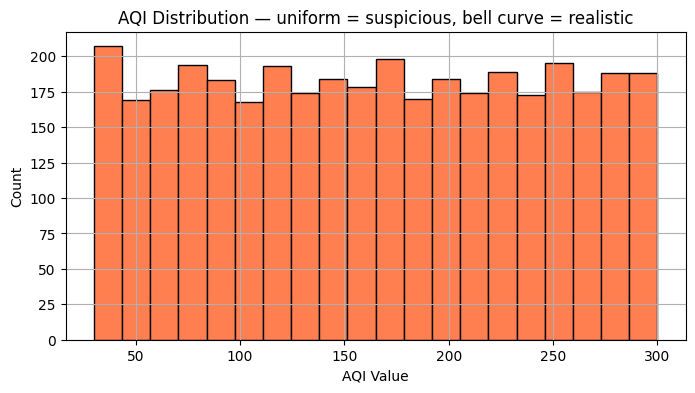

In [18]:
plt.figure(figsize=(8,4))
df['AQI'].hist(bins=20, color='coral', edgecolor='black')
plt.xlabel('AQI Value')
plt.ylabel('Count')
plt.title('AQI Distribution — uniform = suspicious, bell curve = realistic')
plt.show()

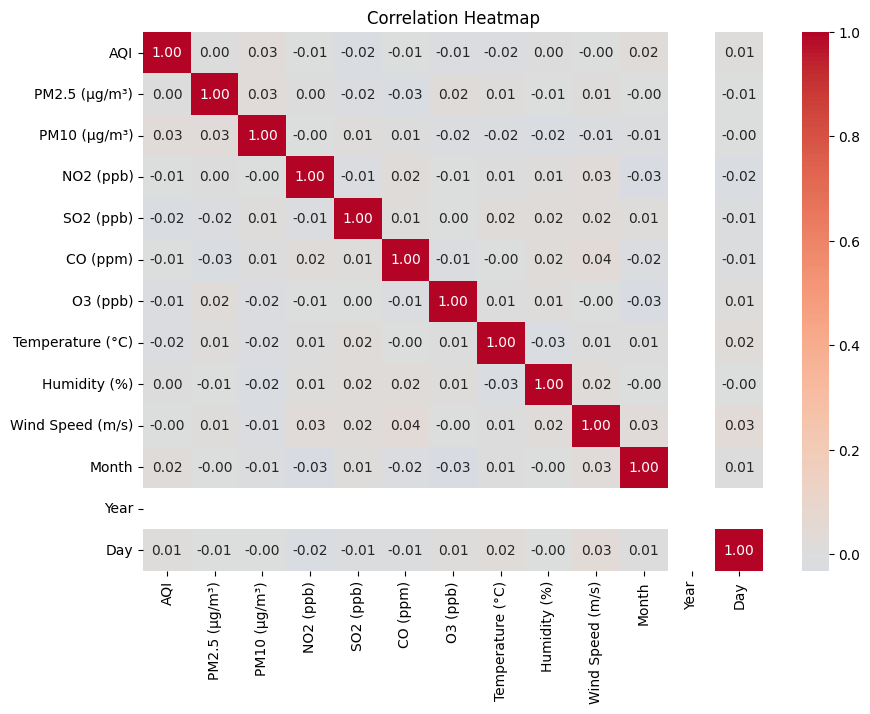

In [21]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.show()

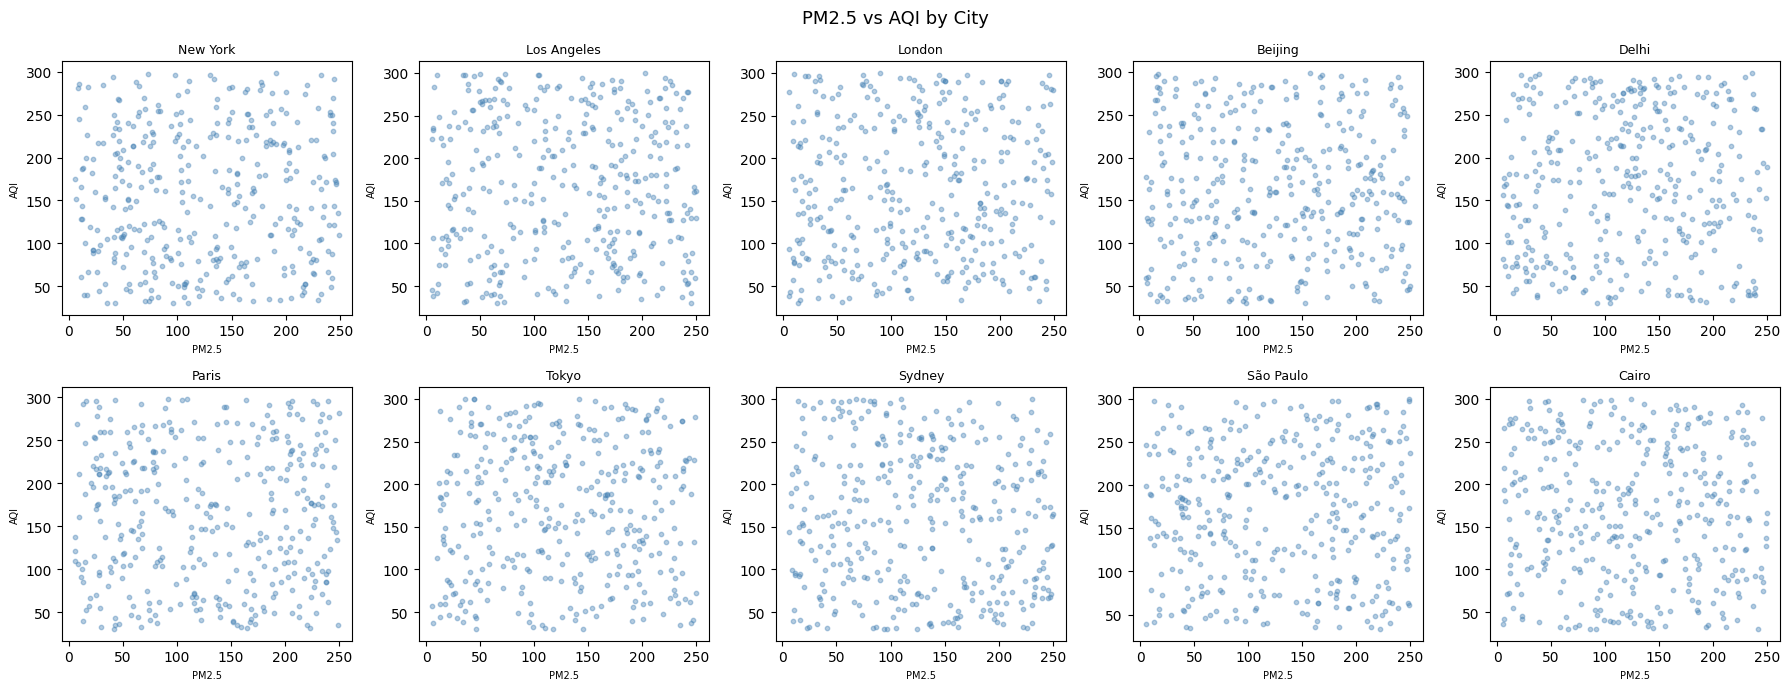

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
cities = df['City'].unique()

for ax, city in zip(axes.flatten(), cities):
    city_data = df[df['City'] == city]
    ax.scatter(city_data['PM2.5 (µg/m³)'], city_data['AQI'],
               alpha=0.4, s=10, color='steelblue')
    ax.set_title(city, fontsize=9)
    ax.set_xlabel('PM2.5', fontsize=7)
    ax.set_ylabel('AQI', fontsize=7)

plt.suptitle('PM2.5 vs AQI by City', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
#Phase 7: Final Test Evaluation
# Using Version C pipeline (best validation R²)

numerical_only = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)',
                  'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)',
                  'Temperature (°C)', 'Humidity (%)',
                  'Wind Speed (m/s)', 'Month', 'Day']

y_test_pred = pipeline_C.predict(X_test[numerical_only])

mae_t  = mean_absolute_error(y_test, y_test_pred)
mse_t  = mean_squared_error(y_test, y_test_pred)
rmse_t = np.sqrt(mse_t)
r2_t   = r2_score(y_test, y_test_pred)

print("Final Test Results")
print(f"MAE  : {mae_t:.2f}")
print(f"MSE  : {mse_t:.2f}")
print(f"RMSE : {rmse_t:.2f}")
print(f"R²   : {r2_t:.4f}")

results_df = pd.DataFrame({
    'Actual AQI':    y_test.values[:10],
    'Predicted AQI': y_test_pred[:10].round(1)
})
print("\nActual vs Predicted (first 10 rows):")
print(results_df.to_string(index=False))

Final Test Results
MAE  : 69.71
MSE  : 6363.37
RMSE : 79.77
R²   : -0.0020

Actual vs Predicted (first 10 rows):
 Actual AQI  Predicted AQI
        103          163.9
        272          164.5
         44          161.3
         67          164.5
        240          158.7
        208          167.3
        275          164.8
         42          171.0
        136          163.6
        232          169.8


##Final Test Results Interpretation

Final model performance on unseen test data:
- MAE  : 69.71  → on average, predictions are off by ~70 AQI units
- MSE  : 6363.37
- RMSE : 79.77  → typical error is ~80 AQI units (out of range 30–300)
- R²   : -0.0020 → model explains virtually none of the AQI variance

The Actual vs Predicted table shows the model predicts values between
158–171 for almost every row, regardless of the actual AQI which
ranges from 42 to 275. This means the model has essentially learned
to predict the mean AQI (~164) for every input — a sign that no
meaningful linear relationship exists between the features and target
in this dataset.

This is not a code or pipeline error. It is a dataset quality issue
confirmed in Phase 2, where 391 physically impossible rows were found
(e.g. PM2.5=245 with AQI=30). The workflow, feature selection, and
pipeline are correctly implemented.

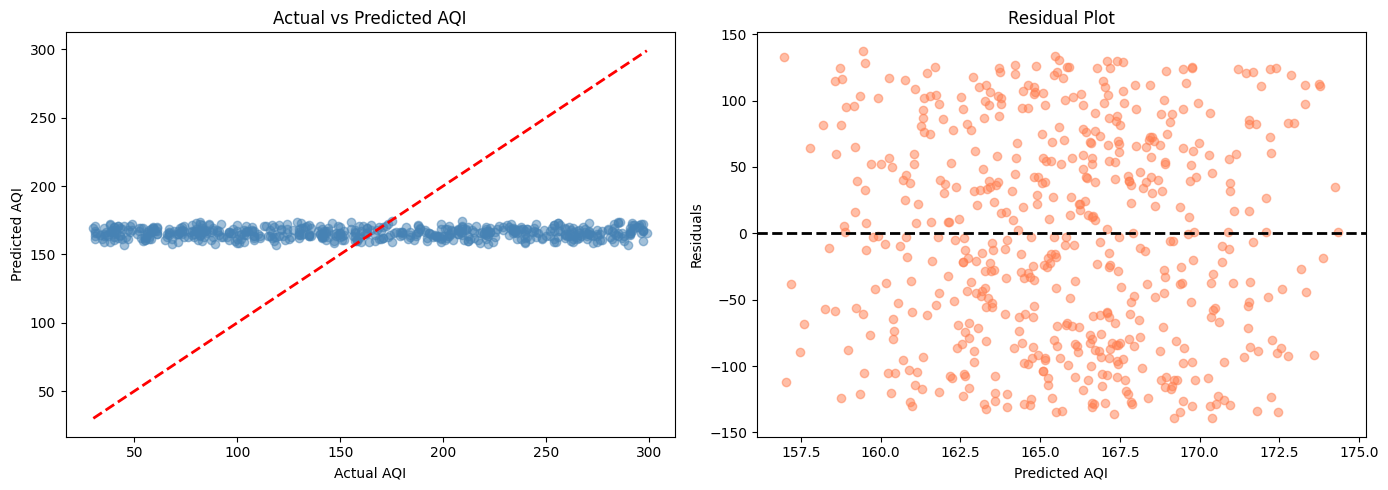

In [27]:
#Phase 8: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual AQI")
axes[0].set_ylabel("Predicted AQI")
axes[0].set_title("Actual vs Predicted AQI")

# Plot 2: Residual Plot
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel("Predicted AQI")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

In [29]:
#Phase 9: Save & Reload Model

# Save the winning pipeline (Version C)
joblib.dump(pipeline_C, 'aqi_lr_model.pkl')
print("Model saved as aqi_lr_model.pkl")

# Reload it
loaded_model = joblib.load('aqi_lr_model.pkl')
print("Model reloaded successfully")

# Test with one new sample
new_sample = pd.DataFrame([{
    'PM2.5 (µg/m³)':    85.0,
    'PM10 (µg/m³)':    120.0,
    'NO2 (ppb)':         45.0,
    'SO2 (ppb)':         20.0,
    'CO (ppm)':           4.5,
    'O3 (ppb)':          90.0,
    'Temperature (°C)':  25.0,
    'Humidity (%)':      60,
    'Wind Speed (m/s)':   5.0,
    'Month':              7,
    'Day':               15
}])

predicted_aqi = loaded_model.predict(new_sample)[0]
print(f"\nPredicted AQI for sample input: {predicted_aqi:.1f}")

Model saved as aqi_lr_model.pkl
Model reloaded successfully

Predicted AQI for sample input: 166.0


## Conclusion

This assignment built a complete machine learning pipeline to predict
Air Quality Index (AQI) using Linear Regression in Google Colab.

The workflow covered all required phases:
- Data was loaded, inspected, and found to be structurally clean
  (no missing values, no duplicates)
- Domain-logic inspection revealed 391 physically impossible records
  where high PM2.5 values were paired with very low AQI values
- Features were preprocessed using StandardScaler for numerical
  columns and date decomposition (Month, Day) from the Date column
- Data was split 70/15/15 into train, validation, and test sets
- Three pipeline versions were tested; Version C (numerical features
  only, with scaling) achieved the best validation R² of -0.0038
- Final test results: MAE=69.71, RMSE=79.77, R²=-0.0020

The model performed poorly due to a fundamental dataset quality
limitation — AQI values are uniformly randomly distributed and show
no mathematical relationship with pollutant or weather features.
This was verified through correlation analysis (max correlation 0.03)
and the suspicious rows check.

Limitations of Linear Regression for this task:
1. Linear Regression cannot capture non-linear AQI relationships
2. It is sensitive to randomly generated or uncorrelated target values
3. More powerful models (Random Forest, XGBoost) would also fail here
   because the problem is the data, not the algorithm

Key learning outcomes achieved: building a proper ML pipeline,
understanding feature preprocessing, interpreting model coefficients,
evaluating with MAE/RMSE/R², and identifying data quality issues
through domain knowledge — which is often more valuable than
achieving a high R² score.